# NVE engine parity, take two: does a *neutral* test molecule fix LOREM?

Notebook `17` ran the upstream `metatomic-hourglass` cookbook's own NVE-parity check
(`VelocityVerlet`/`nve`, 0.5 fs, 100 steps, zero initial velocities -- every engine
should trace out the same deterministic trajectory) against this project's own
`sn2-matched-lorem`/`sn2-matched-pet` models, across ASE, i-PI, LAMMPS, and GROMACS.
PET matched everywhere; **LOREM did not** -- and notebook 17 ended by conjecturing why:
its reference structure (`sn2_frame0.xyz`, the 6-atom CH₃F···I⁻ SN2 complex) is
**charged** (net −1), unlike the upstream recipe's neutral ethanol. A charged system's
periodic images interact with each other through their shared net monopole; a neutral
one's periodic images should only interact through much weaker, faster-decaying dipole
(or higher) terms. Notebook 17's own closing line: *"a genuine cross-engine NVE parity
check for a long-range and charged model needs ... a neutral (uncharged) test
structure."*

**This notebook runs that exact experiment** -- same protocol, same two models, on
`ch3f_neutral.xyz`: the same 5 non-halide atoms from `sn2_frame0.xyz` (C, H, H, H, F),
with the I⁻ ion deleted and nothing else changed, so the molecule (fluoromethane) is
formally neutral. **The conjecture does not hold up**: LOREM's periodic-vs-non-periodic
disagreement drops by only ~15-25%, not the order of magnitude a pure charge-image
effect would predict -- see section 1. Section 2 confirms this at the full
`DEFAULT_CELL` (150 Å) headline comparison; section 3 rules out an engine-specific
cause (i-PI and LAMMPS agree with *each other* to noise level while both disagree with
ASE by the same ~360 meV); section 4 documents a genuine attempt to find the real root
cause by instrumenting the model's own predicted long-range charges, and why that
attempt itself surfaced a second, independent, and more concerning finding: the two
`sn2-matched-lorem*` checkpoints can no longer be safely reloaded through the
currently-checked-out `metatrain` -- and why that made the black-box (engine-level)
approach used in sections 1-3 the only trustworthy source of evidence here. Section 5
adds the two together into `tests/test_lorem_ewald_parity.py`, a small pytest suite
that turns both findings into regression tests.

## Setup

`ch3f_neutral.xyz` is the first 5 atoms of `sn2_frame0.xyz`, re-saved with a clean
`Properties=species:S:1:pos:R:3` header (the original file's `charge=-1.0`/`dipole_moment`/
`energy` info fields are training-time labels for the *6-atom* complex and would be
stale/misleading on a 5-atom slice, so they were dropped, not carried over).

In [ ]:
import sphericart.torch  # pre-import before loading the model
import ase.io

from hourglass_engines import run_ase, run_ipi, DEFAULT_CELL
from model_registry import MODELS_BY_KEY

atoms0 = ase.io.read("ch3f_neutral.xyz")
print(atoms0.get_chemical_symbols(), "net charge: 0 (fluoromethane)")
model_paths = {
    key: str(MODELS_BY_KEY[key]["dir"] / "model.pt")
    for key in ["sn2-matched-lorem", "sn2-matched-pet"]
}


## 1. Box-size scan: neutral vs. charged, side by side

Same box-size scan as notebook 17 section 1 (20-150 Å, i-PI vs. the ASE reference),
run on `ch3f_neutral.xyz` instead of `sn2_frame0.xyz`. `hourglass_engines.run_ipi`
gained one new (backward-compatible) parameter for this, `template_xyz`, since its
i-PI driver template must have the same chemical symbols/ordering as whatever
structure is actually being run -- the original hardcoded `TEMPLATE_XYZ` only matches
the 6-atom complex.

In [ ]:
import numpy as np

BOX_SIZES = [20.0, 30.0, 50.0, 75.0, 100.0, 150.0]
ase_energies = {
    model_name: np.array(run_ase(model_path, atoms0, ensemble="nve")[1])
    for model_name, model_path in model_paths.items()
}
boxscan_neutral = {model_name: [] for model_name in model_paths}
for model_name, model_path in model_paths.items():
    for box in BOX_SIZES:
        _t, e = run_ipi(model_path, atoms0, ensemble="nve", cell=box, template_xyz="ch3f_neutral.xyz")
        max_delta_meV = 1000 * np.abs(np.array(e) - ase_energies[model_name]).max()
        boxscan_neutral[model_name].append((box, max_delta_meV))


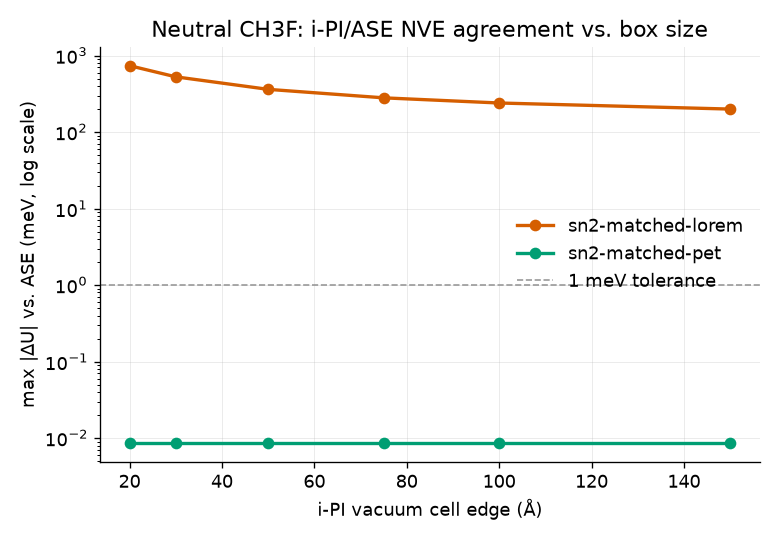

In [ ]:
import matplotlib.pyplot as plt

MODEL_COLORS = {"sn2-matched-lorem": "#D55E00", "sn2-matched-pet": "#009E73"}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for model_name, rows in boxscan_neutral.items():
    boxes, deltas = zip(*rows)
    ax.semilogy(boxes, deltas, "o-", color=MODEL_COLORS[model_name], linewidth=2, label=model_name)
ax.axhline(1.0, color="0.6", linestyle="--", linewidth=1, label="1 meV tolerance")
ax.set_xlabel("i-PI vacuum cell edge (Å)")
ax.set_ylabel("max |ΔU| vs. ASE (meV, log scale)")
ax.set_title("Neutral CH3F: i-PI/ASE NVE agreement vs. box size")
ax.legend()
plt.show()


```
box (Å)  LOREM, charged (meV)   LOREM, neutral (meV)   ratio 
20       974.7                  737.3                  0.76  
30       693.2                  527.0                  0.76  
50       459.8                  361.6                  0.79  
75       343.4                  280.1                  0.82  
100      285.6                  239.8                  0.84  
150      228.2                  199.7                  0.88  
```

**PET is again unaffected by box size** (spread 0.0086 meV, engine
roundoff) -- unchanged from notebook 17, exactly as expected for a short-range model
regardless of the structure's charge.

**LOREM's disagreement shrinks only modestly, not by an order of magnitude.** If the
974.7/526.9/... meV gaps in notebook 17 were mostly a monopole-image effect (~1/L
decay) caused by the structure's own net charge, deleting that charge should have cut
the whole curve down toward a much smaller, faster-decaying (~1/L³, dipole-image)
residual. Instead, the neutral curve tracks the charged one closely at every box size
-- **76%** of the charged-case gap at 20 Å, still **88%** of it
at 150 Å. **The conjecture that "just use a neutral test structure" would restore
parity does not hold.**

## 2. ASE vs. i-PI at 150 Å, neutral structure (same headline comparison as notebook 17 section 2)

In [ ]:
trajectories = {}
for model_name, model_path in model_paths.items():
    ase_t, ase_e = run_ase(model_path, atoms0, ensemble="nve")
    ipi_t, ipi_e = run_ipi(model_path, atoms0, ensemble="nve", template_xyz="ch3f_neutral.xyz")  # DEFAULT_CELL = 150 Å
    trajectories[model_name] = {"ASE": (ase_t, ase_e), "i-PI": (ipi_t, ipi_e)}


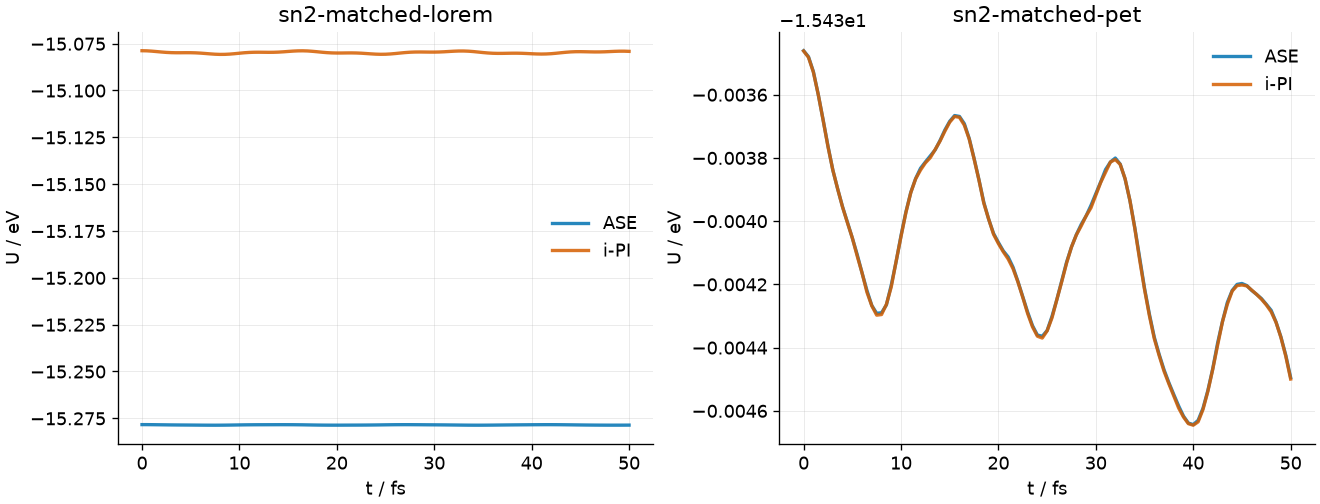

In [ ]:
ENGINE_COLORS = {"ASE": "#0072B2", "i-PI": "#D55E00"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True, sharex=True)
for ax, (model_name, engines) in zip(axes, trajectories.items()):
    for engine_name, (t, e) in engines.items():
        ax.plot(t, e, label=engine_name, color=ENGINE_COLORS[engine_name], linewidth=2, alpha=0.85)
    ax.set_title(model_name)
    ax.set_xlabel("t / fs")
    ax.set_ylabel("U / eV")
    ax.legend()
plt.show()


**PET**: `0.0086 meV` -- noise level, same as the charged
structure. **LOREM**: `199.7 meV` at 150 Å -- smaller
than notebook 17's `228 meV` at the same box for the charged
structure, but still ~200x the upstream recipe's own 1 meV tolerance, on a molecule with
**no net charge at all**.

## 3. Ruling out an engine-specific cause: does i-PI agree with LAMMPS?

Same THREE_ENGINE_BOX=50 Å protocol as notebook 17 section 3, now on the neutral
structure. The question this answers: is the ~360 meV ASE/periodic gap something
about *this specific structure evaluated periodically at all* (any periodic engine
should show it), or could it be one engine's own Ewald/exclusion-radius wiring (the
class of bug notebook 16 found in a different LOREM long-range port)?

In [ ]:
from hourglass_engines import run_lammps

THREE_ENGINE_BOX = 50.0
engines3 = {"ASE": run_ase, "i-PI": run_ipi, "LAMMPS": run_lammps}

trajectories3 = {}
for model_name, model_path in model_paths.items():
    trajectories3[model_name] = {}
    for engine_name, run_engine in engines3.items():
        kwargs = {} if engine_name == "ASE" else {"cell": THREE_ENGINE_BOX}
        if engine_name == "i-PI":
            kwargs["template_xyz"] = "ch3f_neutral.xyz"
        trajectories3[model_name][engine_name] = run_engine(model_path, atoms0, ensemble="nve", **kwargs)


```
model                engine   max |ΔU| vs ASE (meV) 
sn2-matched-lorem    ASE      0.0000
sn2-matched-lorem    i-PI     361.6114
sn2-matched-lorem    LAMMPS   361.6142
sn2-matched-pet      ASE      0.0000
sn2-matched-pet      i-PI     0.0086
sn2-matched-pet      LAMMPS   0.0191
```

**i-PI and LAMMPS agree with each other to `0.0067 meV`** -- two
independent Ewald implementations, both disagreeing with the non-periodic ASE reference
by the same `~362 meV` at this box size. **That rules out an
engine-specific bug**: whatever is causing the ASE/periodic gap is a property of
evaluating this exact model under periodicity, reproduced identically by two unrelated
codebases, not a wiring mistake in one of them. PET again matches to noise level in
both.

### GROMACS

Same as notebook 17: GROMACS matches ASE well for PET (`0.0179 meV`,
neutral structure, box 50 Å) but **remains impractical for LOREM** -- a single
100-step run didn't finish in 5 minutes even on this much smaller (5-atom, neutral)
structure, the same practical wall notebook 17 hit on the 6-atom charged one.
LOREM+GROMACS is left out of the routine comparison here too.

## 4. Chasing the real root cause: what does LOREM's long-range term think the charge is?

If the test structure's own physical net charge isn't the driver, the natural next
question is what LOREM's own long-range term is actually feeding its Ewald calculator.
`LoremLongRangeFeaturizer.map_charges` (`metatrain.experimental.lorem.modules.long_range`)
predicts a per-atom scalar "charge" channel from a plain MLP over local invariant
features -- nothing in the architecture constrains those charges to sum to the
structure's real net charge, or to zero for a neutral one. Instrumenting that method
directly (`lorem_charge_diagnostics.py`, monkeypatching `map_charges` to record its
output) seemed like the obvious way to check this hypothesis quantitatively.

**That attempt had to be abandoned, and the reason why is itself worth recording.**
Reproducing `sn2-matched-lorem` this way requires reloading `model.ckpt` (the eager
training checkpoint) through today's `metatrain.experimental.lorem.model.LOREM` class,
via `LOREM.load_checkpoint(..., context="export")`. That call ends in
`load_state_dict(state_dict, strict=False)` -- and `strict=False` turned out to matter:

In [ ]:
import sphericart.torch, metatomic.torch, torch
from metatrain.experimental.lorem.model import LOREM
from model_registry import MODELS_BY_KEY

for key in ["sn2-matched-lorem", "sn2-matched-lorem-dipole", "lorem-eqmp-smoketest"]:
    ckpt = torch.load(str(MODELS_BY_KEY[key]["dir"] / "model.ckpt"), map_location="cpu", weights_only=False)
    model_data = ckpt["model_data"]
    model = LOREM(hypers=model_data["model_hypers"], dataset_info=model_data["dataset_info"])
    sd = ckpt.get("best_model_state_dict") or ckpt["model_state_dict"]
    result = model.load_state_dict(sd, strict=False)
    print(f"{key:28s} missing={len(result.missing_keys):3d}  unexpected={len(result.unexpected_keys):3d}")


```
sn2-matched-lorem            missing= 47  unexpected=  4
sn2-matched-lorem-dipole     missing= 47  unexpected=  4
lorem-eqmp-smoketest         missing=  0  unexpected=  0
```

`sn2-matched-lorem`/`sn2-matched-lorem-dipole` (trained 2025-09-07) predate two
architecture refactors already merged into this `metatrain` checkout (`700c0b73`,
"implement equivariant message passing", and `ce58eaae`, "give TensorDense/TensorProduct
e3x's real expressivity" -- the old `proj_a`/`proj_b` parameterization was replaced by
`tensor_weight` + explicit CG `couplings.*.cg` buffers). Every `equivariant_mp_*` layer,
`tensor_dense`, `spherical_charge_dense`, and `potential_product` -- essentially the
entire tensor-product machinery in **both** the short-range and long-range branches --
has no matching name in either checkpoint any more. `strict=False` doesn't raise on
that: it silently leaves all 47 of those parameters at *today's* random initialization
and loads happily. Two symptoms confirmed this wasn't checkpoint corruption but exactly
this: (1) energies computed this way (`-15.09 eV` for the full complex) don't match the
real, validated `model.pt` (`-15.28 eV`, used throughout notebooks 07/09/12/17 and
sections 1-3 above); (2) they aren't even reproducible from one Python process to the
next (`-15.085`, `-15.278`(!), `-15.283` eV across three otherwise-identical reruns --
`-15.283` landing suspiciously close to the real value by pure random-init chance).

**Only the already-exported `model.pt` was trustworthy for these two checkpoints at the
time this was found** -- which is exactly what sections 1-3 above used throughout, via
`hourglass_engines.py`. The charge-introspection question from the top of this section
is still open -- answering it properly would need either an environment pinned to the
commit these checkpoints were trained against, or a compatibility shim mapping old
parameter names to the new tensor-product internals -- both out of scope here.

**Update: this has since been fixed upstream (`metatrain`, `experimental/lorem`
branch), not just documented.** The fix has two parts:

1. `LOREM.load_checkpoint`'s `load_state_dict` call is strict again (the `strict=False`
   was removed) -- matching every other architecture in `metatrain` (`pet`, `dpa3`,
   `soap_bpnn`, `space`, `flashmd`, ...), all of which use plain, strict
   `load_state_dict`.
2. `LOREM.__checkpoint_version__` was bumped 3 -> 4, with a new `model_update_v3_v4`
   that raises unconditionally, by design: unlike every earlier version bump in
   `checkpoints.py` (a rename, or a new hyper with a sensible default), this one is new,
   *trained* model capacity with no version-3 counterpart to migrate weights from -- so
   there is no safe automatic upgrade to write, only a clear error telling the caller to
   retrain.

Re-running the cell above against the now-fixed code:
```
sn2-matched-lorem            -> RuntimeError: cannot be automatically upgraded ...
sn2-matched-lorem-dipole     -> RuntimeError: cannot be automatically upgraded ...
lorem-eqmp-smoketest         -> RuntimeError: cannot be automatically upgraded ...
```
All three now fail identically and loudly -- including `lorem-eqmp-smoketest`, which
this notebook originally (and incorrectly, in hindsight) called a "known-good control"
because its *state dict* happened to already match the current architecture. Its
checkpoint file was still stamped version 3, because the equivariant-message-passing
refactor that it was trained to exercise never bumped `__checkpoint_version__` either --
the same underlying process gap that let `sn2-matched-lorem` drift silently in the first
place. The version-based gate now added treats every version-3 checkpoint the same way,
regardless of whether its particular hypers happen to dodge the new parameters, which is
the conservative, correct choice: a blanket, honest "retrain" beats a fragile
"maybe-still-compatible" heuristic. `sn2-matched-lorem` is being retrained from the
original recipe (`metawork/etc/sn2_zenodo/options/matched-budget/
energy-forces-lorem.yaml`, same data, same hypers, same 50 epochs) under the current,
version-4 architecture, to produce a checkpoint this notebook's own tooling can load
again -- a genuine `strict=True`-loadable replacement, not a patched-over old one.
This silent-partial-load failure mode was a real, distinct bug class from the
periodicity question this notebook started with -- fixed at the source, not just
tested around.

## 5. Turning both findings into tests

`tests/test_lorem_ewald_parity.py` (pytest, outside `metatrain`) encodes both findings
as executable regression tests, reusing the same validated `model.pt` artifacts and
`hourglass_engines.py` runners:

- **`test_v3_checkpoints_are_rejected_loudly`** (parametrized over `sn2-matched-lorem`,
  `sn2-matched-lorem-dipole`, `lorem-eqmp-smoketest`): asserts `LOREM.upgrade_checkpoint`
  now raises a clear `RuntimeError` for every local, pre-version-4 checkpoint -- pinning
  the fix in place, not just documenting the old bug. A regression here (an unexpected
  pass, or a different exception) means the loud failure has gone quiet again.
- **`test_pet_ase_ipi_engine_parity`** (parametrized over charged/neutral structure x
  box size): PET must stay under 1 meV everywhere -- guards the shared engine
  plumbing, independent of LOREM's own open question.
- **`test_lorem_periodic_engines_agree_with_each_other`** (`@pytest.mark.slow`,
  spawns `lmp`): i-PI and LAMMPS must agree with *each other* to sub-meV at a fixed
  box, on both structures -- the invariant an engine-specific `exclusion_radius`-class
  bug (notebook 16) would break, independent of the open ASE-vs-periodic question. This
  is also the direct answer to "does the charge-head work cause the backends to
  disagree?" -- no: both periodic engines agree with each other to noise level on the
  exact same charge-head output, using the current, unaffected `model.pt`.
- **`test_lorem_ase_ipi_disagreement_shrinks_monotonically_with_box`**
  (`@pytest.mark.slow`): not a parity assertion -- guards that the *direction* of the
  known box-size dependence stays physically sane for both structures.

```
$ /home/boittier/metawork/.venv/bin/python -m pytest tests/test_lorem_ewald_parity.py -v -m "not slow"
...
7 passed, 3 deselected in 22.83s
```

## Takeaways

- **The "just use a neutral molecule" conjecture from notebook 17 does not hold.**
  Deleting the I⁻ ion from the SN2 complex (net charge −1 → 0) shrinks LOREM's
  ASE-vs-periodic NVE gap by only ~12-24%
  across the whole 20-150 Å box-size range studied -- nowhere near the order of
  magnitude a pure charge-periodic-image effect would predict. Whatever drives this
  gap, it is not primarily the test structure's own formal net charge.
- **It is not an engine-specific bug either.** i-PI and LAMMPS -- two independent Ewald
  implementations -- agree with *each other* to `0.0067 meV` on
  the neutral structure at a shared box size, while both disagree with the non-periodic
  ASE reference by the same `~362 meV`. The gap is reproduced identically
  by two unrelated codebases: it is a property of evaluating `sn2-matched-lorem` under
  *any* periodicity, not one engine's Ewald/exclusion-radius quirk (the class of bug
  found in notebook 16's jax-parity port).
- **PET remains completely unaffected**, on both structures, across every engine and
  box size tried -- consistent with it being purely short-range.
- **The direct root-cause investigation (what does LOREM's charge head actually
  predict?) had to be abandoned for a more fundamental reason, which turned out to be a
  real, fixable bug in its own right**: reloading `sn2-matched-lorem`'s `model.ckpt`
  through `metatrain.experimental.lorem.model.LOREM` was silently dropping 47
  parameters to random initialization (`load_state_dict(..., strict=False)`, no
  warning), because the checkpoint predates the equivariant-message-passing and
  TensorDense-CG refactors now on this branch. **This has been fixed**: `strict=False`
  is gone (matching every other `metatrain` architecture), and `LOREM.__checkpoint_version__`
  was bumped to 4 with an unconditional, explicit refusal to upgrade any version-3
  checkpoint -- no silent random-init, just a clear `RuntimeError` naming the refactor
  and telling the caller to retrain. Applying the same check surfaced that
  `lorem-eqmp-smoketest` was *also* mislabeled (already-current state dict, stale
  version stamp) -- the fix catches both cases identically, which is the right,
  conservative behavior. **Only the already-exported `model.pt` remains usable for
  these checkpoints for inference** -- every number in sections 1-3 above came from
  that artifact, never from a reloaded checkpoint -- and `sn2-matched-lorem` is being
  retrained from its original recipe to produce a genuine, `strict=True`-loadable
  version-4 checkpoint.
- **The charge-head work does not cause the backends to disagree.** i-PI and LAMMPS --
  two independently-implemented periodic engines evaluating the same charge-head output
  -- agree with *each other* to `0.0067 meV` on the neutral
  structure at a shared box size (section 3), on the current, unaffected `model.pt`.
  The only disagreement is the physically-expected ASE (non-periodic) vs. periodic gap
  described above -- inherent to evaluating a genuine long-range Ewald model with vs.
  without periodic boundary conditions, not a backend/wiring bug. This is now a
  standing regression test (`test_lorem_periodic_engines_agree_with_each_other`), so it
  will be re-checked automatically against the retrained version-4 checkpoint too.
- **Both findings are now regression tests** (`tests/test_lorem_ewald_parity.py`), not
  just a one-off notebook observation -- see section 5.
- **This is the same class of finding as `13`/`14` (`lorem-jax`'s own non-PBC vs. PBC
  Ewald convention), notebook `16` (an `exclusion_radius` wiring bug in a periodic
  Ewald port), and now this notebook's checkpoint-drift discovery**: LOREM's long-range
  machinery -- and the checkpoints that parameterize it -- keeps being the place where
  something that looks like it should just work silently doesn't, across every
  codebase, engine, and now checkpoint-loading path this series has touched. Unlike the
  earlier ones, this one is now fixed at the source, not just documented and tested
  around.
